#Top

[![Open in GitHub](https://img.shields.io/badge/Open%20Folder%20in-GitHub-181717?logo=github&logoColor=white)](https://github.com/lindsayalexandra14/ds_portfolio/tree/main/1_projects/statistical_analysis/matching_propensity_scores)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/lindsayalexandra14/ds_portfolio/blob/main/1_projects/statistical_analysis/matching_propensity_scores/matching_propensity_scores_r_google_colab.ipynb)

#Matching with Propensity Scores

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Matching%20with%20Propensity%20Scores.png)

**analysis**
*   This propensity score matching analysis is performed on the Lalonde data which was gathered to evaluate the NSW (National Supported Work) Demonstration experiment of the 1970's. The experiment tested a labor training program to see if it improved the earnings (income in 1978) for disadvantaged workers. The experiment also sought to evaluate the accuracy of observational studies vs. randomized trials, as the experiment was a randomized trial and then was additionally analyzed with observational studies.

**result**
*  It was established that there was not a significant causal effect based on the observational study (1246 dollar increase in income but no signficance). In the original randomized trial there was a significant causal effect (800 dollar increase in income), which shows that there must have been unobserved variables between the worker groups, and the observational study is therefore biased.

**recommendation**
*  If there had not been a randomized trial and there were to be a recommendation based strictly on the observational study / propensity score matching analysis, it should not be recommended that the labor training program be implemented.

# Setup

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Setup.png)

## Install Packages

In [ ]:
install.packages("tableone")
install.packages("Matching")
install.packages("MatchIt")
install.packages("sysfonts")
install.packages("showtext")
install.packages("ggplot2")
install.packages("optmatch")

## Load Libraries

In [ ]:
library(tableone)
library(Matching)
library(MatchIt) # lalonde data is in the MatchIt package
library(sysfonts)
library(showtext)
library(ggplot2)
library(dplyr)
library(optmatch)

#Data

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Data.png)

## View Data

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/View%20Data.png)

In [ ]:
data(lalonde)

In [ ]:
mydata<-lalonde

The data have n=614 subjects and 9 variables:

In [ ]:
dim(mydata)

[1] 614   9

In [ ]:
head(mydata)

,treat,age,educ,race,married,nodegree,re74,re75,re78
,<int>,<int>,<int>,<fct>,<int>,<int>,<dbl>,<dbl>,<dbl>
NSW1,1,37,11,black,1,1,0,0,9930.0460
NSW2,1,22,9,hispan,0,1,0,0,3595.8940
NSW3,1,30,12,black,0,0,0,0,24909.4500
NSW4,1,27,11,black,0,1,0,0,7506.1460
NSW5,1,33,8,black,0,1,0,0,289.7899
NSW6,1,22,9,black,0,1,0,0,4056.4940


In [ ]:
tail(mydata)

,treat,age,educ,race,married,nodegree,re74,re75,re78
,<int>,<int>,<int>,<fct>,<int>,<int>,<dbl>,<dbl>,<dbl>
PSID424,0,25,14,white,0,0,0,0,0.0000
PSID425,0,18,11,white,0,1,0,0,10150.5000
PSID426,0,24,1,hispan,1,1,0,0,19464.6100
PSID427,0,21,18,white,0,0,0,0,0.0000
PSID428,0,32,5,black,1,1,0,0,187.6713
PSID429,0,16,9,white,0,1,0,0,1495.4590


In [ ]:
head(rownames(mydata))

[1] "NSW1" "NSW2" "NSW3" "NSW4" "NSW5" "NSW6"

Confirming there are two prefixes/indices only (NSW - experiment data, PSID control data):

In [ ]:
prefixes <- gsub("[0-9_]", "", rownames(mydata))

In [ ]:
unique(prefixes)


[1] "NSW"  "PSID"

View summary statistics:

In [ ]:
summary(mydata)

     treat             age             educ           race        married      
 Min.   :0.0000   Min.   :16.00   Min.   : 0.00   black :243   Min.   :0.0000  
 1st Qu.:0.0000   1st Qu.:20.00   1st Qu.: 9.00   hispan: 72   1st Qu.:0.0000  
 Median :0.0000   Median :25.00   Median :11.00   white :299   Median :0.0000  
 Mean   :0.3013   Mean   :27.36   Mean   :10.27                Mean   :0.4153  
 3rd Qu.:1.0000   3rd Qu.:32.00   3rd Qu.:12.00                3rd Qu.:1.0000  
 Max.   :1.0000   Max.   :55.00   Max.   :18.00                Max.   :1.0000  
    nodegree           re74            re75              re78        
 Min.   :0.0000   Min.   :    0   Min.   :    0.0   Min.   :    0.0  
 1st Qu.:0.0000   1st Qu.:    0   1st Qu.:    0.0   1st Qu.:  238.3  
 Median :1.0000   Median : 1042   Median :  601.5   Median : 4759.0  
 Mean   :0.6303   Mean   : 4558   Mean   : 2184.9   Mean   : 6792.8  
 3rd Qu.:1.0000   3rd Qu.: 7888   3rd Qu.: 3249.0   3rd Qu.:10893.6  
 Max.   :1.0000   Ma

Variable definitions:


*   age: age in years
*   educ: years of schooling
*   black: indicator variable for Blacks
*   hispan: indicator variable for Hispanics
*   married: indicator variable for marital status
*   nodegree: indicator variable for high school diploma
*   re74: real earnings in 1974
*   re75: real earnings in 1975
*   re78: real earnings in 1978
*   treat: an indicator variable for treatment status (1 if the subject received the labor training and equal to 0 otherwise)
*   The outcome is re78 – post-intervention income

# Pre-processing

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Pre-Processing.png)

View & change datatypes to numeric:

In [ ]:
sapply(mydata, class)

treat       age      educ      race   married  nodegree      re74      re75 
"integer" "integer" "integer"  "factor" "integer" "integer" "numeric" "numeric" 
     re78 
"numeric"

In [ ]:
mydata$hispan<-as.numeric(mydata$race=="hispan")
mydata$black<-as.numeric(mydata$race=="black")
treat<-as.numeric(mydata$treat==1)
married<-as.numeric(mydata$married==1)
nodegree<-as.numeric(mydata$nodegree==1)

Assign x variables:

In [ ]:
xvars=c("treat","age","educ","black","hispan","married","nodegree","re74","re75")

##Standardized differences

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Standardized%20Differences.png)

Compute difference in means for each x variable, between groups. The groups are control (0) vs. treatment (1). Formula: (mean x_treatment - mean_x_control) / (square root ((s_squared_treatment+s_squared_control) / 2)) where s is the pooled standard deviation.

*   smd < 0.1 signals adequate balance
*   smd > 0.2 signals serious imbalance

In [ ]:
table1<-CreateTableOne(vars=xvars,strata="treat",data=mydata, test=FALSE)
print(table1,smd=TRUE)

                      Stratified by treat
                       0                 1                 SMD   
  n                        429               185                 
  treat (mean (SD))       0.00 (0.00)       1.00 (0.00)       Inf
  age (mean (SD))        28.03 (10.79)     25.82 (7.16)     0.242
  educ (mean (SD))       10.24 (2.86)      10.35 (2.01)     0.045
  black (mean (SD))       0.20 (0.40)       0.84 (0.36)     1.668
  hispan (mean (SD))      0.14 (0.35)       0.06 (0.24)     0.277
  married (mean (SD))     0.51 (0.50)       0.19 (0.39)     0.719
  nodegree (mean (SD))    0.60 (0.49)       0.71 (0.46)     0.235
  re74 (mean (SD))     5619.24 (6788.75) 2095.57 (4886.62)  0.596
  re75 (mean (SD))     2466.48 (3292.00) 1532.06 (3219.25)  0.287


Treatment Income in 1978:

In [ ]:
y_trt<-mydata$re78[treat==1]
print(head(y_trt))

[1]  9930.0460  3595.8940 24909.4500  7506.1460   289.7899  4056.4940


Control Income in 1978:

In [ ]:
y_con<-mydata$re78[treat==0]
print(head(y_con))

[1] 25564.67 25564.67 25564.67 15491.01     0.00 17833.20


Difference between treatment & control:

Raw/unadjusted mean of real earnings in 1978 for treated vs. control:


In [ ]:
mean(y_trt)-mean(y_con)

[1] -635.0262

#Propensity scores

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Propensity%20Scores.png)

Use logistic regression to calculate propensity scores. This regresses the treatment on the x variables:

In [ ]:
psmodel<-glm(treat~age+educ+black+hispan+married+nodegree+re74+re75,family=binomial(),data=mydata)
summary(psmodel)


Call:
glm(formula = treat ~ age + educ + black + hispan + married + 
    nodegree + re74 + re75, family = binomial(), data = mydata)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -4.729e+00  1.017e+00  -4.649 3.33e-06 ***
age          1.578e-02  1.358e-02   1.162  0.24521    
educ         1.613e-01  6.513e-02   2.477  0.01325 *  
black        3.065e+00  2.865e-01  10.699  < 2e-16 ***
hispan       9.836e-01  4.257e-01   2.311  0.02084 *  
married     -8.321e-01  2.903e-01  -2.866  0.00415 ** 
nodegree     7.073e-01  3.377e-01   2.095  0.03620 *  
re74        -7.178e-05  2.875e-05  -2.497  0.01253 *  
re75         5.345e-05  4.635e-05   1.153  0.24884    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 751.49  on 613  degrees of freedom
Residual deviance: 487.84  on 605  degrees of freedom
AIC: 505.84

Number of Fisher Scoring iterations: 5


Extracts propensity score values:

In [ ]:
pscore<-psmodel$fitted.values

In [ ]:
min(round(pscore,4))
max(round(pscore,4))
length(pscore)

[1] 0.0091

[1] 0.8532

[1] 614

Print coefficients with clearer/expanded numbers:

In [ ]:
print(coef(psmodel))

  (Intercept)           age          educ         black        hispan 
-4.728649e+00  1.577707e-02  1.613069e-01  3.065368e+00  9.836336e-01 
      married      nodegree          re74          re75 
-8.321133e-01  7.072969e-01 -7.177669e-05  5.344645e-05 


Add propensity scores into the data:

In [ ]:
mydata <- cbind(mydata, pscore)

View propensity score distributions between treatment vs. control groups:

This histogram shows that the groups have different distributions and would benefit from matching to achieve balance:

Warning message:
“The dot-dot notation (`..count..`) was deprecated in ggplot2 3.4.0.
ℹ Please use `after_stat(count)` instead.”


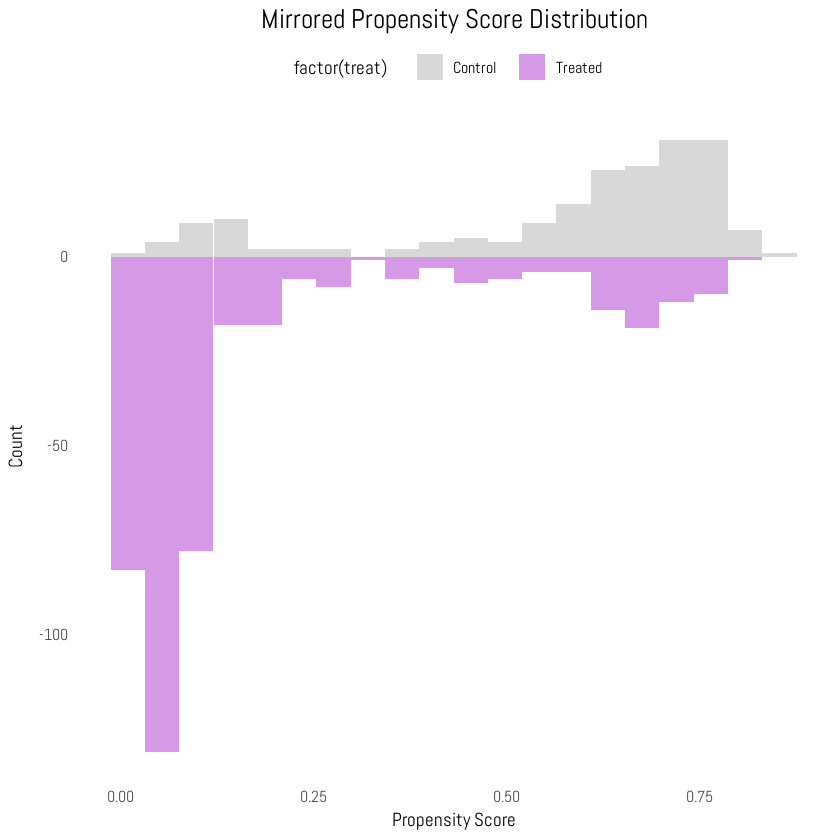

In [ ]:
df <- data.frame(ps = pscore, treat = factor(treat))

font_add_google("Abel", "abel")
showtext_auto()

ggplot(df, aes(x = ps, fill = factor(treat))) +
  geom_histogram(
    data = subset(df, treat == 1),
    bins = 20, alpha = 0.6
  ) +
  geom_histogram(
    data = subset(df, treat == 0),
    bins = 20, alpha = 0.6,
    aes(y = -..count..)   # flip control group to negative y
  ) +
  labs(title = "Mirrored Propensity Score Distribution",
       x = "Propensity Score", y = "Count") +
  scale_fill_manual(values = c("gray", "mediumorchid"),
                    labels = c("Control", "Treated")) +
  theme_minimal()+
  theme(panel.grid.major = element_blank(),
      panel.grid.minor = element_blank())  +
  theme(
    plot.title = element_text(hjust = 0.5, size = 20, face = "bold", family = "abel"),
    axis.title.x = element_text(size = 14, face = "bold", family = "abel"),
    axis.title.y = element_text(size = 14, face = "bold", family = "abel"),
    legend.position = "top",
    legend.title = element_text(size = 14, face = "bold", family = "abel"),
    legend.text = element_text(size = 12, family = "abel"),
    axis.text.x = element_text(size = 12, family = "abel"),
    axis.text.y = element_text(size = 12, family = "abel")
)

#Matching

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Matching.png)

Match treatment subjects with control subjects based on similar propensity scores:

Pair matching, without replacement, no caliper.   
Matched on the propensity score itself (not logit of the propensity score)


Obtained the standardized differences for the matched data. Note that several are far above the threshold of 0.1, showing imbalance:

In [ ]:
set.seed(931139)

psmatch_no_caliper<-Match(Tr=mydata$treat,M=1,X=pscore,replace=FALSE)
matched_no_caliper<-mydata[unlist(psmatch_no_caliper[c("index.treated","index.control")]),]
matchedtab_no_caliper<-CreateTableOne(vars=xvars,strata="treat",data=matched_no_caliper,test=FALSE)
print(matchedtab_no_caliper,smd=TRUE)

                      Stratified by treat
                       0                 1                 SMD   
  n                        185               185                 
  treat (mean (SD))       0.00 (0.00)       1.00 (0.00)       Inf
  age (mean (SD))        25.29 (10.65)     25.82 (7.16)     0.058
  educ (mean (SD))       10.55 (2.71)      10.35 (2.01)     0.084
  black (mean (SD))       0.47 (0.50)       0.84 (0.36)     0.852
  hispan (mean (SD))      0.21 (0.41)       0.06 (0.24)     0.453
  married (mean (SD))     0.20 (0.40)       0.19 (0.39)     0.027
  nodegree (mean (SD))    0.65 (0.48)       0.71 (0.46)     0.127
  re74 (mean (SD))     2351.12 (4192.62) 2095.57 (4886.62)  0.056
  re75 (mean (SD))     1605.02 (2601.68) 1532.06 (3219.25)  0.025


Match on propensity score (with caliper):

Pair matching, without replacement, with caliper of 0.1. The caliper is a maximum acceptable distance of the best match.   

Note how smds (standard mean differences) are much lower/more acceptable now:

In [ ]:
set.seed(931139)

psmatch<-Match(Tr=mydata$treat,M=1,X=pscore,replace=FALSE, caliper=0.1)
matched<-mydata[unlist(psmatch[c("index.treated","index.control")]),]
matchedtab<-CreateTableOne(vars=xvars,strata="treat",data=matched,test=FALSE)
print(matchedtab,smd=TRUE)

                      Stratified by treat
                       0                 1                 SMD   
  n                        111               111                 
  treat (mean (SD))       0.00 (0.00)       1.00 (0.00)       Inf
  age (mean (SD))        26.27 (11.10)     26.22 (7.18)     0.006
  educ (mean (SD))       10.37 (2.66)      10.25 (2.31)     0.047
  black (mean (SD))       0.72 (0.45)       0.74 (0.44)     0.040
  hispan (mean (SD))      0.11 (0.31)       0.10 (0.30)     0.029
  married (mean (SD))     0.24 (0.43)       0.24 (0.43)    <0.001
  nodegree (mean (SD))    0.66 (0.48)       0.65 (0.48)     0.019
  re74 (mean (SD))     2704.56 (4759.89) 2250.49 (5746.14)  0.086
  re75 (mean (SD))     1969.10 (3169.08) 1222.25 (3081.19)  0.239


View matched pairs, showing their pair_id and their propensity scores:

In [ ]:
# Group treated vs. control
treated  <- mydata[psmatch$index.treated, ]
control  <- mydata[psmatch$index.control, ]

# Add ID for each treated/control pair
# Indices were already ordered in matching order for treatment & control in matching function
pair_id <- seq_along(psmatch$index.treated)
treated$pair_id <- pair_id
control$pair_id <- pair_id

# Add propensity score
treated$pscore <- pscore[psmatch$index.treated]
control$pscore <- pscore[psmatch$index.control]

matched_pairs <- merge(
  treated[, c("pair_id", "treat", "pscore")],
  control[, c("pair_id", "treat", "pscore")],
  by = "pair_id",
  suffixes = c(".treated", ".control")
)

head(matched_pairs)

,pair_id,treat.treated,pscore.treated,treat.control,pscore.control
,<int>,<int>,<dbl>,<int>,<dbl>
1,1,1,0.6387699,0,0.6385542
2,2,1,0.2246342,0,0.2240794
3,3,1,0.6782439,0,0.6787886
4,4,1,0.7763241,0,0.7789115
5,5,1,0.7016387,0,0.7050850
6,6,1,0.6990699,0,0.6934766


Add outcome (re78), to be used in a later section below:

In [ ]:
# Group treated vs. control
treated  <- mydata[psmatch$index.treated, ]
control  <- mydata[psmatch$index.control, ]

# Add an ID for each treated/control pair
# Indices were already ordered in matching order for treatment & control in matching function
pair_id <- seq_along(psmatch$index.treated)
treated$pair_id <- pair_id
control$pair_id <- pair_id

# Add propensity score
treated$pscore <- pscore[psmatch$index.treated]
control$pscore <- pscore[psmatch$index.control]

matched_pairs_w_outcome <- merge(
  treated[, c("pair_id", "treat", "pscore", "re78")],
  control[, c("pair_id", "treat", "pscore", "re78")],
  by = "pair_id",
  suffixes = c(".treated", ".control")
)

head(matched_pairs_w_outcome)

,pair_id,treat.treated,pscore.treated,re78.treated,treat.control,pscore.control,re78.control
,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
1,1,1,0.6387699,9930.0460,0,0.6385542,14421.1300
2,2,1,0.2246342,3595.8940,0,0.2240794,1525.0140
3,3,1,0.6782439,24909.4500,0,0.6787886,2158.9590
4,4,1,0.7763241,7506.1460,0,0.7789115,701.9201
5,5,1,0.7016387,289.7899,0,0.7050850,14344.2900
6,6,1,0.6990699,4056.4940,0,0.6934766,8900.3470


Reformat chart for updated histogram of propensity score distribution:

In [ ]:
treat_vec <- rep(1, length(psmatch$index.treated))
control_vec <- rep(0, length(psmatch$index.control))

df_matched <- data.frame(
  pair_id,
  treat   = c(treat_vec, control_vec),
  pscore  = c(pscore[psmatch$index.treated], pscore[psmatch$index.control])
)

head(df_matched)


,pair_id,treat,pscore
,<int>,<dbl>,<dbl>
NSW1,1,1,0.6387699
NSW2,2,1,0.2246342
NSW3,3,1,0.6782439
NSW4,4,1,0.7763241
NSW5,5,1,0.7016387
NSW6,6,1,0.6990699


Note there are 222 pairs that were matched:

In [ ]:
dim(df_matched)

[1] 222   3

Make chart for matched that can go into histograph. pscore & treated vs. control only

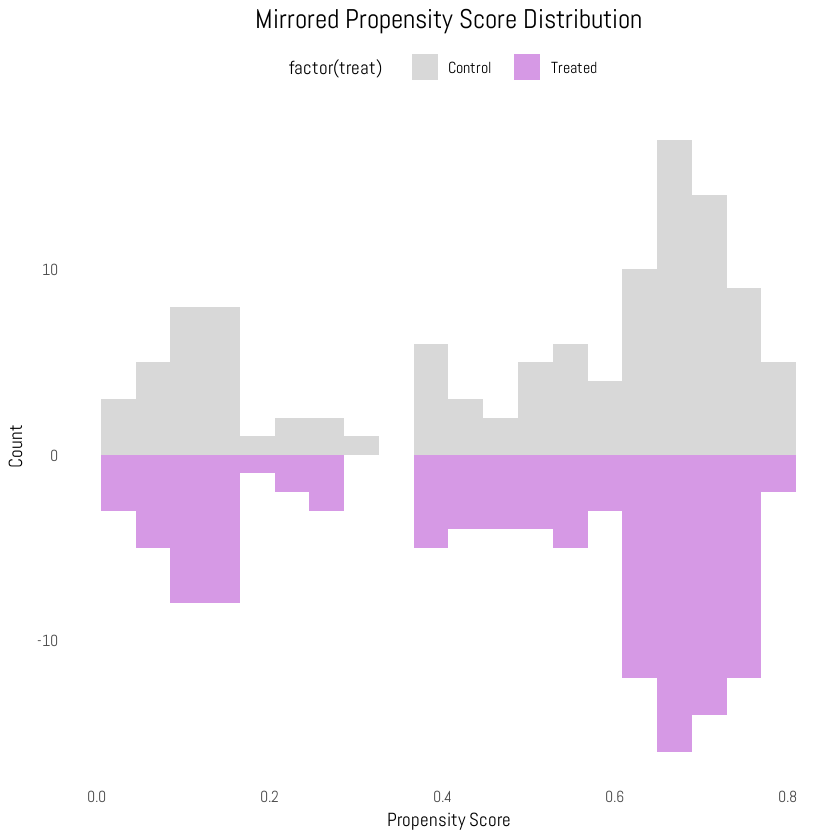

In [ ]:
ggplot(df_matched, aes(x = pscore, fill = factor(treat))) +
  geom_histogram(
    data = subset(df_matched, treat == 1),
    bins = 20, alpha = 0.6
  ) +
  geom_histogram(
    data = subset(df_matched, treat == 0),
    bins = 20, alpha = 0.6,
    aes(y = -..count..)   # flip control group to negative y
  ) +
  labs(title = "Mirrored Propensity Score Distribution",
       x = "Propensity Score", y = "Count") +
  scale_fill_manual(values = c("gray", "mediumorchid"),
                    labels = c("Control", "Treated")) +
  theme_minimal()+
  theme(panel.grid.major = element_blank(),
      panel.grid.minor = element_blank())  +
  theme(
    plot.title = element_text(hjust = 0.5, size = 20, face = "bold", family = "abel"),
    axis.title.x = element_text(size = 14, face = "bold", family = "abel"),
    axis.title.y = element_text(size = 14, face = "bold", family = "abel"),
    legend.position = "top",
    legend.title = element_text(size = 14, face = "bold", family = "abel"),
    legend.text = element_text(size = 12, family = "abel"),
    axis.text.x = element_text(size = 12, family = "abel"),
    axis.text.y = element_text(size = 12, family = "abel")
)

##Results

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Results.png)

Label treatment subjects:

In [ ]:
matched$treat<-as.numeric(matched$treat==1)

Income in 1978 for treated & control subjects (displayed separately & just the first few):

In [ ]:
y_trt_matched<-matched$re78[matched$treat==1]
head(y_trt_matched)

[1]  9930.0460  3595.8940 24909.4500  7506.1460   289.7899  4056.4940

In [ ]:
y_con_matched<-matched$re78[matched$treat==0]
head(y_con_matched)

[1] 14421.1300  1525.0140  2158.9590   701.9201 14344.2900  8900.3470

Confirming length of each (111) matches up with 222 pairs:

In [ ]:
length(y_con_matched)

[1] 111

Mean income in 1978 for treated & control:

In [ ]:
mean(y_trt_matched)

[1] 6151.181

In [ ]:
mean(y_con_matched)

[1] 4904.375

Difference in average income in 1978 between treated vs. control subjects:

In [ ]:
mean(y_trt_matched)-mean(y_con_matched)

[1] 1246.806

In [ ]:
diffy<-y_trt_matched-y_con_matched

In [ ]:
print(head(diffy))

[1]  -4491.084   2070.880  22750.491   6804.226 -14054.500  -4843.853


![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Significance.png)

A t-Test was performed to compare the difference between the two means:

For matched data, the difference in means of real earnings in 1978 for treated vs. control is 1246. This result is not signficant given the p-value of 0.14.



95% confidence interval is also -420 - 2913, and therefore it includes 0, meaning there is no strong evidence in a difference in the means between treatment vs. control in the matched data

"diffy" is already the paired difference, so a simple one-sample t-test on diffy is equivalent to a paired t-test.

In [ ]:
t.test(diffy)


	One Sample t-test

data:  diffy
t = 1.4824, df = 110, p-value = 0.1411
alternative hypothesis: true mean is not equal to 0
95 percent confidence interval:
 -420.0273 2913.6398
sample estimates:
mean of x 
 1246.806 


#Sensitivity Analysis

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Sensitivity%20Analysis.png)

When treatment labels were randomly shuffled 1,000x, ~12.9% of the random shuffles produced an average difference at least as large as the $1246 difference, showing the difference could easily arise by chance (p-value: 0.129>0.05).    

The difference was not siginficant to begin with, and the permutation test also supports that the difference is not significant.


In [ ]:
# Per-pair differences
matched_pairs_w_outcome$diff <- matched_pairs_w_outcome$re78.treated - matched_pairs_w_outcome$re78.control

# Observed mean difference
obs_diff <- mean(matched_pairs_w_outcome$diff)
cat("Observed mean difference (treated - control):", obs_diff, "\n")

# Permutation test
set.seed(100)
n_iter <- 1000
perm_diffs <- numeric(n_iter)

for (i in 1:n_iter) {
  # Randomly flip the sign of the pair differences (simulates swapping treatment labels)
  flip <- sample(c(-1, 1), nrow(matched_pairs_w_outcome), replace = TRUE)
  perm_diffs[i] <- mean(matched_pairs_w_outcome$diff * flip)
}

# Observed vs. permutation distribution
p_value <- mean(abs(perm_diffs) >= abs(obs_diff))
cat("Permutation p-value:", p_value, "\n")


Observed mean difference (treated - control): 1246.806 
Permutation p-value: 0.129 


This chart of the permutation test shows the 1,000 random shuffles. The 12.9% of differences/shuffles that are above the 1246 observed difference are the grey bars to the right of the observed purple bar. With it being so far to the right, it shows that there is some evidence of a treatment effect but that it is still not technically statistically signficant:

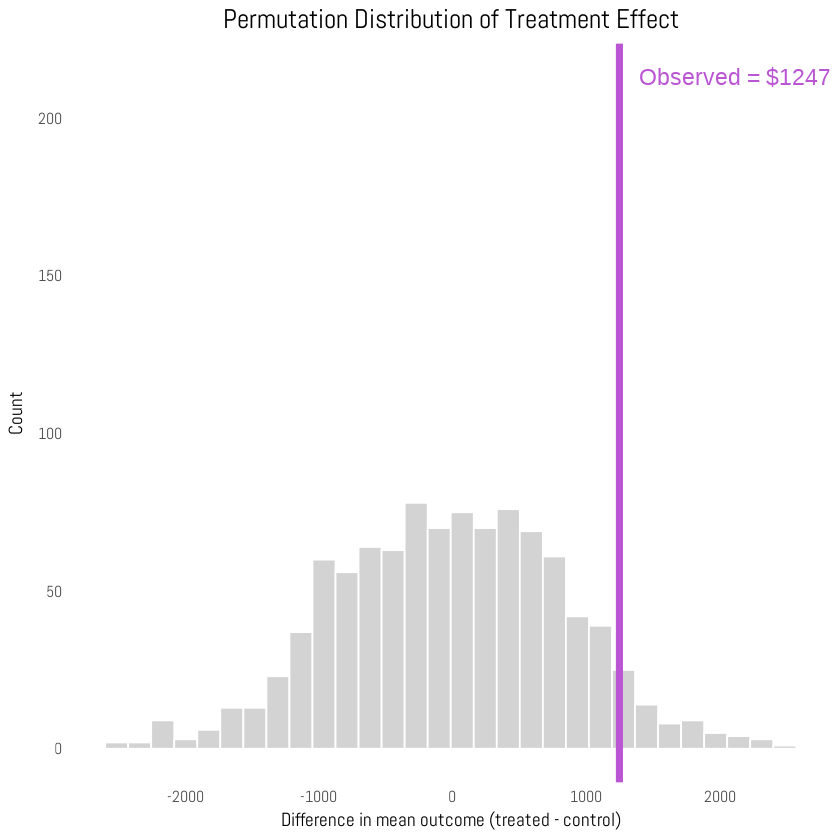

In [ ]:
perm_df <- data.frame(perm_diffs = perm_diffs)

suppressWarnings(ggplot(perm_df, aes(x = perm_diffs)) +
  geom_histogram(bins = 30, fill = "lightgray", color = "white") +
  geom_vline(xintercept = obs_diff, color = "mediumorchid", size = 2) +
  annotate("text", x = obs_diff,
           y = max(hist(perm_diffs, plot = FALSE)$counts),
           label = paste0("Observed = $", round(obs_diff, 0)),
           hjust = -.1, color = "mediumorchid", size =6) +
  labs(
    title = "Permutation Distribution of Treatment Effect",
    x = "Difference in mean outcome (treated - control)",
    y = "Count"
  ) +
  theme_minimal() +
  theme(
    panel.grid.major = element_blank(),
    panel.grid.minor = element_blank(),
    plot.title = element_text(hjust = 0.5, size = 20, face = "bold", family = "abel"),
    axis.title.x = element_text(size = 14, face = "bold", family = "abel"),
    axis.title.y = element_text(size = 14, face = "bold", family = "abel"),
    axis.text.x = element_text(size = 12, family = "abel"),
    axis.text.y = element_text(size = 12, family = "abel")
  ))


This function performs a sensitivity analysis runs results at different caliper levels. The chart below it shows that (given their p-values) the conclusion of no significance remains the same:

In [ ]:
psm_sensitivity <- function(data, treatment, xvars, outcome, pscore, cal) {

  set.seed(931139)

  # Ensure numeric inputs
  pscore <- as.numeric(pscore)
  outcome_vec <- as.numeric(data[[outcome]])

  # Matching
  psmatch <-
    Match(Y= data[[outcome]],Tr = data[[treatment]], M = 1, X = pscore, replace = FALSE,
    caliper = cal,version="standard", Var.calc = TRUE)

  # Extract matched data
  matched <- data[unlist(psmatch[c("index.treated","index.control")]), ]

  # TableOne for covariate balance
  matched_tab <- CreateTableOne(vars = xvars, strata = treatment, data = matched, test = FALSE)
  smd_vals <- ExtractSmd(matched_tab)
  smd_vals[!is.finite(smd_vals)] <- NA
  max_smd <- if(length(smd_vals)==0) NA else max(abs(smd_vals), na.rm=TRUE)

  # Treatment effect & p-value
  sum_match <- summary(psmatch)
  treat_effect <- if(length(psmatch$est)==0) NA else round(as.numeric(psmatch$est),2)

  # Number of matched observations
  n_matched <- nrow(matched)

  matched$treat<-as.numeric(matched$treat==1)
  y_trt_matched<-matched$re78[matched$treat==1]
  y_con_matched<-matched$re78[matched$treat==0]
  diffy<-y_trt_matched-y_con_matched
  t_result<-t.test(diffy)
  p_value_ttest <- t_result$p.value

  return(data.frame(
    caliper = cal,
    n_matched = n_matched,
    treat_effect = treat_effect,
    p_value = p_value_ttest,
    max_smd = max_smd
  ))
}


Chart of different caliper levels (in matching) showing that (given their p-values) the conclusion of no significance remains the same:

In [ ]:
caliper_values <- c(0.05, 0.1, 0.2, 0.25, 0.3)
results_list <- list()

for(cal in caliper_values) {
  result <- psm_sensitivity(mydata, "treat", xvars, "re78", pscore, cal)
  if(!is.null(result)) results_list[[as.character(cal)]] <- result
}

sensitivity_summary <- do.call(rbind, results_list)
print(sensitivity_summary)



Estimate...  1200.6 
SE.........  912.88 
T-stat.....  1.3152 
p.val......  0.18844 

Original number of observations..............  614 
Original number of treated obs...............  185 
Matched number of observations...............  108 
Matched number of observations  (unweighted).  108 

Caliper (SDs)........................................   0.05 
Number of obs dropped by 'exact' or 'caliper'  77 


Estimate...  1246.8 
SE.........  837.29 
T-stat.....  1.4891 
p.val......  0.13646 

Original number of observations..............  614 
Original number of treated obs...............  185 
Matched number of observations...............  111 
Matched number of observations  (unweighted).  111 

Caliper (SDs)........................................   0.1 
Number of obs dropped by 'exact' or 'caliper'  74 


Estimate...  1168.9 
SE.........  855.52 
T-stat.....  1.3663 
p.val......  0.17184 

Original number of observations..............  614 
Original number of treated obs............

This performs the same type of sensitivity analysis but done testing a different matching method "optimal" using Optmatch package:

In [ ]:
psm_sensitivity <- function(data, treatment, xvars, outcome, pscore, cal) {

  set.seed(931139)

  # Ensure numeric variables
  pscore <- as.numeric(pscore)
  outcome_vec <- as.numeric(data[[outcome]])

  # Matching with "optimal" method using Optmatch package:

  # Create distance matrix from propensity scores for treated vs controls
  dist_mat <- match_on(as.formula(paste(treatment, "~ pscore")), data = data)
  # Apply caliper (width = cal)
  dist_caliper <- caliper(dist_mat, width = cal)
  # Perform optimal full matching with caliper constraint
  matches <- fullmatch(dist_caliper, data = data)


  # Assign match group labels to data
  data$match_group <- matches

  # Subset matched data (remove unmatched)
  matched <- subset(data, !is.na(match_group))

  # Cast treatment column as numeric 0,1 for consistency
  matched$treat_num <- as.numeric(matched[[treatment]] == 1)

  # Covariate balance table in matched sample
  matched_tab <- CreateTableOne(vars = xvars, strata = treatment, data = matched, test = FALSE)
  smd_vals <- ExtractSmd(matched_tab)
  smd_vals[!is.finite(smd_vals)] <- NA
  max_smd <- if(length(smd_vals)==0) NA else max(abs(smd_vals), na.rm=TRUE)

  # Treatment effect estimate (difference in means)
  y_trt_matched <- matched[[outcome]][matched$treat_num == 1]
  y_con_matched <- matched[[outcome]][matched$treat_num == 0]
  treat_effect <- round(mean(y_trt_matched) - mean(y_con_matched), 2)

  # Paired t-test by matched groups (within matched strata)
  # For optimal full matching, paired analysis is more complex.
  # Simplifying: Do unpaired t-test between matched treated and control
  t_result <- t.test(y_trt_matched, y_con_matched)
  p_value_ttest <- t_result$p.value

  # Return summary data frame
  return(data.frame(
    caliper = cal,
    n_matched = nrow(matched),
    treat_effect = treat_effect,
    p_value = p_value_ttest,
    max_smd = max_smd
  ))
}


 This analysis also shows the conclusion still holds (p-values are still showing no significance):

In [ ]:
caliper_values <- c(0.05, 0.1, 0.2, 0.25, 0.3)
results_list <- list()

for(cal in caliper_values) {
  result <- psm_sensitivity(mydata, "treat", xvars, "re78", pscore, cal)
  if(!is.null(result)) results_list[[as.character(cal)]] <- result
}

sensitivity_summary <- do.call(rbind, results_list)
print(sensitivity_summary)


     caliper n_matched treat_effect   p_value  max_smd
0.05    0.05       579      -315.77 0.6457097 1.622312
0.1     0.10       610      -540.02 0.4301027 1.653958
0.2     0.20       613      -634.66 0.3512729 1.663834
0.25    0.25       613      -634.66 0.3512729 1.663834
0.3     0.30       614      -635.03 0.3490767 1.667719


#Results Summary

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Results%20Summary.png)

It was established that there was not a significant causal effect based on the observational study (1246 dollar increase in income but no signficance). This result is valid based on the sensitivity analysis, where the conclusion did not change with various methods and calipers.

In the original randomized trial there was a significant causal effect (800 dollar increase in income), which shows that there must have been unobserved variables between the worker groups, and the observational study is therefore biased.

#Recommendation

![Alt text](https://github.com/lindsayalexandra14/ds_portfolio/raw/main/2_images/templates/notebook/headers/beige/Recommendation.png)

If there had not been a randomized trial and there were to be a recommendation based strictly on the observational study / propensity score matching analysis, it should not be recommended that the labor training program be implemented.